In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

In [5]:
import crosscoders as xc
import torch


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 8192,
        MAX_RECORDS = None,
        MAX_BATCHES = 1000000,
        MAX_TOKENS = 1000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [6]:

from crosscoders.constants import CONSTANTS
from crosscoders.dataclasses.configs.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config


runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)
runner_cfg

RunnerConfig(
    MODEL = ModelConfig(
        CAUSALITY = 'acausal',
        LOCALITY = 'global',
        N_LAYERS = 12,
        D_MODEL = 768,
        D_CODER = 16384,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
    LOSS = AcausalLossConfig(
        L1_COEFFICIENT = 1.0,
    ),
    OPTIMIZER = OptimizerConfig(
        optimizer = <class 'torch.optim.adam.Adam'>,
        parameters = OptimizerParameters(
            lr = 0.002279,
            betas = (0.9, 0.999),
            fused = True,
        ),
    ),
)

In [7]:
from crosscoders.autoencoders.acausal.runner import AcausalAutoencoderRunner


runner = AcausalAutoencoderRunner(runner_cfg)

In [29]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 1000000

In [30]:
from crosscoders.data.dataset import TinyStoriesRayDataset


train_ds = TinyStoriesRayDataset().load('activations')

Metadata Fetch Progress 0:   0%|          | 0.00/83.0 [00:00<?, ? task/s]

Parquet Files Sample 0:   0%|          | 0.00/5.00 [00:00<?, ? file/s]

In [10]:
train_dl = train_ds.iter_torch_batches(
    batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE,
    # local_shuffle_buffer_size=16
    device='cuda'
)

In [11]:
for batch_idx, batch in enumerate(train_dl):

    # loss = runner.training_step(batch)

    # print(loss)

    break

2025-02-14 18:56:12,746	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-14_18-52-24_879061_2856/logs/ray-data
2025-02-14 18:56:12,747	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000 2: 0.00 row [00:00, ? row/s]

In [12]:
x = batch['resid_post']

x_hat = runner.model(x)

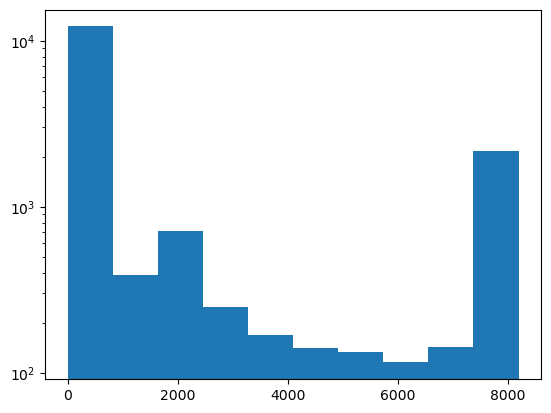

In [33]:
# why use any? why not count how many tokens each neuron is dead for?
runner.model.x_enc.any(dim=0).sum()
plt.hist((runner.model.x_enc == 0).sum(dim=0).cpu().numpy())
plt.yscale('log')

In [13]:
x.shape

torch.Size([1000, 12, 768])

In [16]:
x.norm(dim=-1)

torch.Size([1000, 12])

In [14]:
import numpy as np

np.sqrt(runner_cfg.MODEL.D_MODEL)

27.712812921102035

In [31]:
train_ds

limit=1000000
+- Dataset(
      num_rows=1924184,
      schema={resid_post: numpy.ndarray(shape=(12, 768), dtype=float)}
   )

In [33]:
def get_scalar(batch):

    batch['resid_post_norm_sum'] = [np.linalg.norm(batch['resid_post'], ord=2, axis=-1).sum()]
    # batch['resid_post_norm_count'] = batch['resid_post'].shape[0] * batch['resid_post'].shape[1]
    batch['resid_post_norm_count'] = [batch['resid_post'].shape[0] * batch['resid_post'].shape[1]]

    del batch['resid_post']

    # raise NotImplementedError(batch)

    return batch

stats = train_ds.map_batches(get_scalar).sum()

2025-02-14 19:50:52,183	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-14_18-52-24_879061_2856/logs/ray-data
2025-02-14 19:50:52,183	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=1000000] -> TaskPoolMapOperator[MapBatches(get_scalar)] -> LimitOperator[limit=1]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

- limit=1000000 2: 0.00 row [00:00, ? row/s]

- MapBatches(get_scalar) 3: 0.00 row [00:00, ? row/s]

...

- Aggregate 4: 0.00 row [00:00, ? row/s]

Sort Sample 5:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Map 6:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

Shuffle Reduce 7:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

- limit=1 8: 0.00 row [00:00, ? row/s]

140.60230497021485

In [41]:
scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)
x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

X_SCALAR = np.sqrt(runner_cfg.MODEL.D_MODEL) / x_mean_l2

scaled_model_dim, x_mean_l2, X_SCALAR

(27.712812921102035, 140.60230497021485, 0.19710070135032787)

In [ ]:
def get_x_scalar(ds):
        
    def get_batch_scalar(batch):

        return {
            'resid_post_norm_sum': [np.linalg.norm(batch['resid_post'], ord=2, axis=-1).sum()],
            'resid_post_norm_count': [batch['resid_post'].shape[0] * batch['resid_post'].shape[1]],
        }

    stats = ds.map_batches(get_scalar).sum()


    scaled_model_dim = np.sqrt(runner_cfg.MODEL.D_MODEL)
    x_mean_l2 = stats['sum(resid_post_norm_sum)'] / stats['sum(resid_post_norm_count)']

    X_SCALAR = np.sqrt(runner_cfg.MODEL.D_MODEL) / x_mean_l2

    return scaled_model_dim, x_mean_l2, X_SCALAR


scaled_model_dim, x_mean_l2, X_SCALAR = get_x_scalar(train_ds)

In [42]:
def scale_x(batch, X_SCALAR):

    batch['resid_post'] = X_SCALAR * batch['resid_post']

    return batch


train_ds_scaled = train_ds.map_batches(scale_x, X_SCALAR=X_SCALAR, batch_size=CONSTANTS.EXPERIMENT.BATCH_SIZE)

In [ ]:
# from src.scripts import train


# train.main()

In [215]:
import ray, ray.train
from ray.train.torch import TorchTrainer

from scripts.train import train_loop_per_worker



trainer = TorchTrainer(
    train_loop_per_worker,
    # train_loop_config=ExperimentConfig(),
    scaling_config=ray.train.ScalingConfig(
        num_workers=CONSTANTS.EXPERIMENT.NUM_TRAINERS,
        use_gpu=True,
        resources_per_worker={'CPU': 2, 'GPU': 1}
    ),
    run_config = ray.train.RunConfig(
        # checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1),
        storage_path='s3://crosscoders/ray/'
    ),
    datasets={'train': train_ds_scaled}
)
result: ray.train.Result = trainer.fit()


2025-02-14 21:46:51,454	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2025-02-14 21:46:51 (running for 00:00:00.11)
Using FIFO scheduling algorithm.
Logical resource usage: 0/8 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-46-51/TorchTrainer_2025-02-14_21-46-50/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-14 21:46:56 (running for 00:00:05.13)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-46-51/TorchTrainer_2025-02-14_21-46-50/driver_artifacts
Number of trials: 1/1 (1 PENDING)


== Status ==
Current time: 2025-02-14 21:47:01 (running for 00:00:10.18)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-4

(pid=84175) Running 0: 0.00 row [00:00, ? row/s]

(pid=84175) - ReadParquet->SplitBlocks(2) 1: 0.00 row [00:00, ? row/s]

(pid=84175) - limit=1000000 2: 0.00 row [00:00, ? row/s]

(pid=84175) - MapBatches(scale_x) 3: 0.00 row [00:00, ? row/s]

(pid=84175) - split(1, equal=True) 4: 0.00 row [00:00, ? row/s]

== Status ==
Current time: 2025-02-14 21:47:06 (running for 00:00:15.20)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-46-51/TorchTrainer_2025-02-14_21-46-50/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-14 21:47:11 (running for 00:00:20.22)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-46-51/TorchTrainer_2025-02-14_21-46-50/driver_artifacts
Number of trials: 1/1 (1 RUNNING)


== Status ==
Current time: 2025-02-14 21:47:16 (running for 00:00:25.28)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_

2025-02-14 21:53:58,024	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'crosscoders/ray/TorchTrainer_2025-02-14_21-46-50' in 0.3519s.
2025-02-14 21:53:58,026	INFO tune.py:1041 -- Total run time: 426.57 seconds (426.01 seconds for the tuning loop).


== Status ==
Current time: 2025-02-14 21:53:58 (running for 00:07:06.36)
Using FIFO scheduling algorithm.
Logical resource usage: 3.0/8 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A10G)
Result logdir: /tmp/ray/session_2025-02-14_18-52-24_879061_2856/artifacts/2025-02-14_21-46-51/TorchTrainer_2025-02-14_21-46-50/driver_artifacts
Number of trials: 1/1 (1 TERMINATED)




In [216]:
result

Result(
  metrics={'loss': 1954.968994140625, 'error': 1502.325927734375, 'l1': 452.64306640625, 'l0': 26.32118034362793, 'explained_variance': 0.9053589701652527, 'dead_neurons/all_tokens': 0.0001220703125, 'dead_neurons/one_token': 0.00677490234375, 'dead_neurons/no_token': 0.99322509765625, 'n_tokens': 1000000},
  path='crosscoders/ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51',
  filesystem='s3',
  checkpoint=Checkpoint(filesystem=s3, path=crosscoders/ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000)
)

In [ ]:
checkpoint_path = 's3://crosscoders/ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000'

import boto3
import pathlib


bucket_name = 'crosscoders'
checkpoint_s3_key = 'ray/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000/model.pt'


local = False


# checkpoint_path = '/home/ec2-user/ray_results/TorchTrainer_2025-02-14_20-01-27/TorchTrainer_79606_00000_0_2025-02-14_20-01-27/checkpoint_000000/model.pt'
# local = True



if not local:
    checkpoint_path = '/tmp/crosscoders/checkpoints/TorchTrainer_2025-02-14_21-46-50/TorchTrainer_33270_00000_0_2025-02-14_21-46-51/checkpoint_000000/model.pt'

    with open(checkpoint_path, 'wb') as infl:
        boto3.resource('s3') \
            .Object(bucket_name, checkpoint_s3_key) \
            .download_fileobj(infl)
        

with open(checkpoint_path, 'rb') as infl:
    checkpoint_dict = torch.load(infl)

# # delete tmp file if downloaded from s3
# if delete_tmp_file:
#     pathlib.Path(checkpoint_path).unlink()

checkpoint_dict

OrderedDict([('W_enc',
              tensor([[[-1.3018e-02, -1.3741e-02, -1.4526e-02,  ..., -1.2686e-02,
                        -9.5352e-03, -1.4215e-02],
                       [-1.3013e-02, -1.2230e-02,  7.3981e-04,  ..., -1.1874e-02,
                         3.8257e-03, -1.3029e-02],
                       [-1.3786e-02, -1.4474e-02, -3.3147e-03,  ...,  1.2478e-02,
                        -1.8842e-03, -1.3642e-02],
                       ...,
                       [-1.4143e-02, -1.4973e-02, -1.1224e-02,  ...,  4.7466e-03,
                         4.3838e-03, -1.4092e-02],
                       [ 1.3200e-02, -1.0418e-02,  1.7626e-02,  ...,  1.2362e-02,
                         8.9666e-03,  1.2962e-02],
                       [-1.3390e-02, -1.4669e-02, -1.1253e-02,  ..., -1.1617e-02,
                        -7.3794e-03, -1.3521e-02]],
              
                      [[-1.3661e-02, -2.9965e-03, -1.3777e-02,  ..., -1.3778e-02,
                        -9.0797e-03, -1.3586e-02],
  

In [227]:
from crosscoders.autoencoders.acausal.model import AcausalAutoencoder

model = AcausalAutoencoder(runner_cfg.MODEL)


# with checkpoint.as_directory() as checkpoint_dir

model.load_state_dict(checkpoint_dict)
model.to(runner_cfg.MODEL.HARDWARE.device)
model.eval()

AcausalAutoencoder()

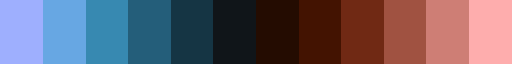

In [228]:
peak_cmap = plt.get_cmap('berlin', runner_cfg.MODEL.N_LAYERS)
peak_cmap

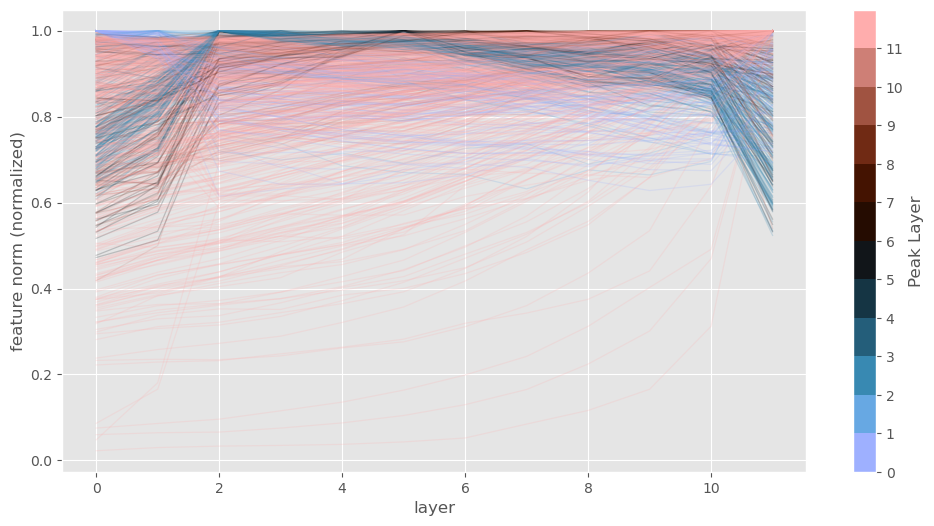

In [229]:
plt.style.use('ggplot')

decoder_norm = model.W_dec.norm(dim=-1)[:1000]
peaks = decoder_norm.max(-1)
peak_colors = peaks.indices.detach().cpu().numpy()
decoder_norm = decoder_norm / peaks.values.unsqueeze(1)
# decoder_norm = decoder_norm.T
decoder_norm = decoder_norm.detach().cpu().numpy()


for i in range(decoder_norm.shape[0]):
    plt.plot(decoder_norm[i], alpha=0.2, linewidth=0.9, color=peak_cmap(peak_colors[i]))




cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=plt.gca())
cbar.set_label('Peak Layer')
cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

plt.gca().set_xlabel('layer')
plt.gca().set_ylabel('feature norm (normalized)')
plt.gcf().set_size_inches(12, 6)

In [175]:
# torch.nn.functional.cosine_similarity(model.W_dec, model.W_enc.transpose(0, -1).transpose(-2, -1), dim=-1).shape
# model.W_enc.transpose(0, -1).transpose(-2, -1).shape

torch.Size([16384, 12])

In [230]:
x = model.W_dec


x_normalized = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
cosine_similarity = x_normalized @ x_normalized.transpose(-2, -1)
cosine_similarity

tensor([[[1.0000, 0.6273, 0.5619,  ..., 0.3231, 0.2498, 0.2064],
         [0.6273, 1.0000, 0.6797,  ..., 0.3603, 0.2952, 0.2256],
         [0.5619, 0.6797, 1.0000,  ..., 0.3946, 0.3292, 0.2788],
         ...,
         [0.3231, 0.3603, 0.3946,  ..., 1.0000, 0.7922, 0.5929],
         [0.2498, 0.2952, 0.3292,  ..., 0.7922, 1.0000, 0.6637],
         [0.2064, 0.2256, 0.2788,  ..., 0.5929, 0.6637, 1.0000]],

        [[1.0000, 0.4553, 0.2838,  ..., 0.0718, 0.0854, 0.0854],
         [0.4553, 1.0000, 0.4559,  ..., 0.2725, 0.2527, 0.1191],
         [0.2838, 0.4559, 1.0000,  ..., 0.4479, 0.4142, 0.1526],
         ...,
         [0.0718, 0.2725, 0.4479,  ..., 1.0000, 0.8742, 0.3919],
         [0.0854, 0.2527, 0.4142,  ..., 0.8742, 1.0000, 0.4137],
         [0.0854, 0.1191, 0.1526,  ..., 0.3919, 0.4137, 1.0000]],

        [[1.0000, 0.6635, 0.6222,  ..., 0.3668, 0.3386, 0.3001],
         [0.6635, 1.0000, 0.7367,  ..., 0.3918, 0.3087, 0.2120],
         [0.6222, 0.7367, 1.0000,  ..., 0.4730, 0.4011, 0.

In [231]:
cossim = cosine_similarity[:10].detach().cpu().numpy()
plt.style.use('default')

Text(0.5, 0, 'layer')

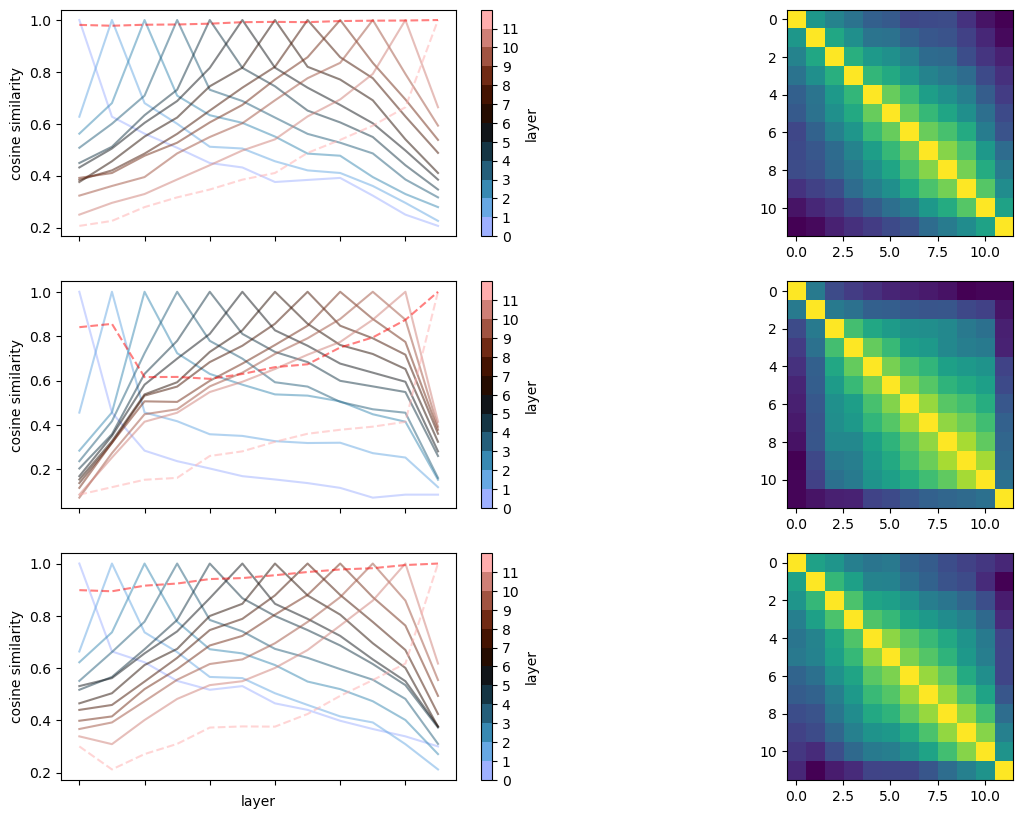

In [232]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))


for i in range(len(ax)):

    for j in range(cossim.shape[1]):
        ax[i][0].plot(cossim[i][j], color=peak_cmap(j), alpha=0.5, linestyle='dashed' if j == peak_colors[i] else 'solid')

    ax[i][0].plot(decoder_norm[i], color='red', alpha=0.5, linestyle='dashed')


    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=peak_cmap, norm=plt.Normalize(vmin=0, vmax=12)), ax=ax[i][0])
    cbar.set_label('layer')
    cbar.set_ticks(range(runner_cfg.MODEL.N_LAYERS))

    ax[i][0].set_ylabel('cosine similarity')
    ax[i][0].set_xticklabels([])


    ax[i][1].imshow(cossim[i])

    

ax[i][0].set_xlabel('layer')